In [21]:
""" Finding count of all Data Job Postings in India """

df_india = df[df['job_country']=="India"].copy()

# Create the month names column
df_india['job_posted_month_name'] = df_india['job_posted_date'].dt.strftime('%B')
# Create the month number column
df_india['job_posted_month_num'] = pd.to_datetime(df_india['job_posted_month_name'], format='%B').dt.month
# df_india = df_india[df_india['job_work_from_home'] == True]
df_india

df_india_pivot = df_india.pivot_table(index=['job_posted_month_num', 'job_posted_month_name'], columns=['job_title_short'] , aggfunc='size')

df_india_pivot.reset_index(inplace=True)
df_india_pivot.drop(columns='job_posted_month_num', inplace=True)
df_india_pivot.set_index('job_posted_month_name', inplace=True)
# df_india_pivot

In [27]:
""" Loading a Similar Dataframe for top Indian Software Jobs """

df_india_software_pivot = pd.read_csv('software_jobs.csv', index_col='job_posted_month_name')
# df_india_software_pivot

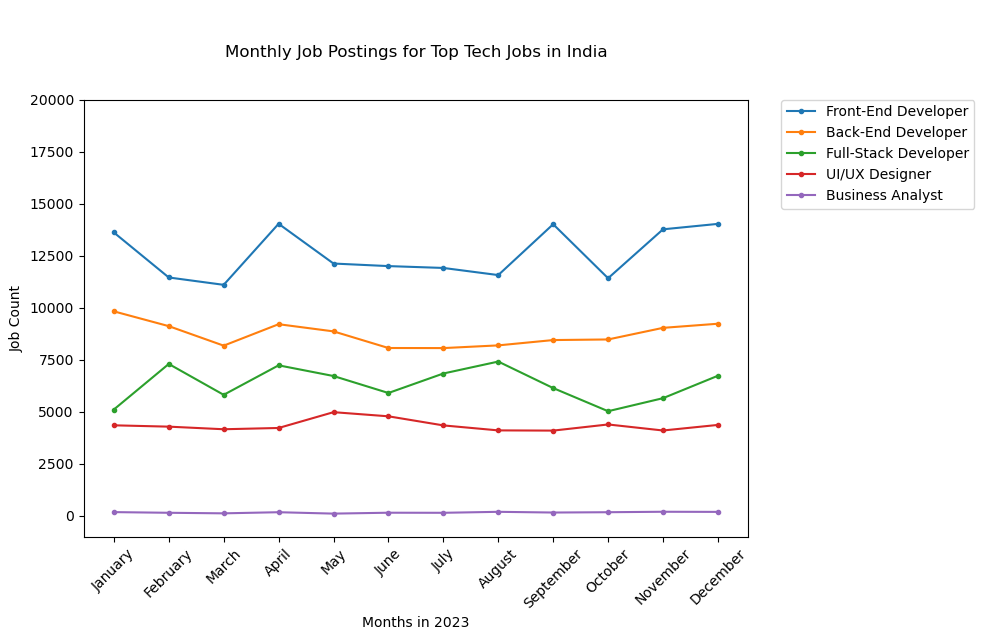

In [58]:
""" Merging the 2 DFs, and then Finding top 5 jobs with the most postings among Data jobs and Software Jobs """

df_merged = df_india_software_pivot.merge(df_india_pivot, on = 'job_posted_month_name')

# .sum() returns the summed up values for every column name, Here job_title_short are the column names
top_5_jobs = list(df_merged.sum().head().index)

df_merged = df_merged[top_5_jobs]

df_merged.plot(kind='line', figsize=(10, 6), marker='.')
plt.title('\n\nMonthly Job Postings for Top Tech Jobs in India\n\n')
plt.xlabel('Months in 2023')
plt.ylabel('Job Count')
# Set the Y-axis range: (bottom_limit, top_limit)
plt.ylim(-1000, 20000)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout() # Crucial: makes room so the legend isn't cut off
# Force show all month names on the X-axis
plt.xticks(ticks=range(len(df_india_pivot.index)), labels=df_india_pivot.index, rotation=45)
plt.show()
